# Week 2 Seminar.

### Course: Machine Learning, 2025/2026, HSE
### Author: Saraa Ali, Teaching Team.

In this exercise we will explore some of the datasets included in the textbook and will build our starter notebook for Kaggle competition

<small><font color=gray>Notebook author: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a>, <a href="https://www.hse.ru/en/staff/sara/" target="_blank">Saraa Ali</a>  ©2026 onwards</font></small><hr style="margin:0;background-color:silver">

**[<font size=6>Your first Kaggle Competition - 💎Diamonds- 26 </font>](https://www.kaggle.com/competitions/26-first-kaggle-competition-diamonds/rules)**. [**Instructions**](https://colab.research.google.com/drive/1owkYjuRGkx050LQnM3b3yTzd0Dr2XbeV) for running Colabs.

In [ ]:
# allows us to print multiple outputs from a single Colab cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# load important libraries that we will use
import time
import numpy as np, pandas as pd, matplotlib.pylab as plt
import seaborn as sns, statsmodels.api as sm
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import r2_score

# Increase viewable area of Pandas tables, numpy arrays, plots
pd.set_option('display.max_rows', 15, 'display.max_columns', 500, 'display.max_colwidth', 1, 'display.precision', 2)
np.set_printoptions(linewidth=10000, precision=4, edgeitems=20, suppress=True)
plt.rcParams['figure.figsize'] = [16, 6]

# Kaggle preparation

## Seminar 2 - Kaggle Competition Setup

### Step 1: Decide how you will work

First, decide whether you will:

* work **solo**,
* work **in a group** (1–3 students), or
* be **assigned to a random team**.

If you want to be assigned to a **random team**, you must **explicitly tell us in advance**, **before the deadline** (in the chat group-topic: kaggle).


### Step 2: Assign yourself to a team in Smart LMS

Regardless of your choice:

1. Go to **Group choice** in Smart LMS
   👉 [https://edu.hse.ru/mod/choicegroup/view.php?id=1950925&forceview=1](https://edu.hse.ru/mod/choicegroup/view.php?id=1950925&forceview=1)

2. Choose one of the following:

   * **Solo**: assign yourself to an empty group
   * **Group**: all team members assign themselves to the same group
   * **Random team**: notify the teaching team **before the deadline** and do not self-assign

⚠️ If the deadline passes and you are **not assigned to any Smart LMS group**, you will be **assigned to a random team automatically**, **with a penalty**.

There are **no manual fixes after the deadline**.


### Step 3: Read the assignment description

Go to the assignment page in Smart LMS and **read it carefully**:

👉 [https://edu.hse.ru/mod/assign/view.php?id=1950903](https://edu.hse.ru/mod/assign/view.php?id=1950903)

This page defines:

* deadlines and penalties
* notebook submission rules
* reproducibility requirements
* grading logic

Don't ignore this information please :(

### Step 4: Create a team in Kaggle

Join the Kaggle competition:

**Seminar 2 = Kaggle time**
👉 [https://www.kaggle.com/t/e3b9bf7540074da2b362c7eea77130f9](https://www.kaggle.com/t/e3b9bf7540074da2b362c7eea77130f9)

Then:

* Create or join a **Kaggle team**
* The **team name must match Smart LMS**, using the format:

```
SmartLMS_TeamName-anything_you_want
```

Example:

```
A-04-lightgbm-v1
```

⚠️ If the Kaggle team name does not clearly match Smart LMS, the submission may be graded as **0**.

### Step 5: What happens after the deadline

After the deadline:

* You **cannot** create or change Smart LMS groups
* Requests to assistants or teachers may be **declined**
* Students without a Smart LMS group will be:

  * assigned to a **random team**
  * receive a **penalty**
  * graded based on the **new assigned team’s result**, even if they worked with someone else on Kaggle

Plan ahead.


### Step 6: Final check before coding

Before you start working on the notebook, make sure:

* You are in a **Smart LMS group**
* All teammates match **exactly**
* Your **Kaggle team exists** and matches Smart LMS
* You understand the **deadlines and penalties**

If this is wrong, it will cost you points.



Let's define a convenience function which rounds our answers up to two decimal points and saves df under `fname.csv`

In [ ]:
def to_csv(df: pd.DataFrame, fname: str) -> None:
  df.round(2).to_csv(f'{fname}.csv', index_label='id')

## Keep track of time!

### Make beautiful outputs in a console

For that we may use ANSI escape sequences which are a standard to control cursor location, color, font styling, and other options on terminal emulators (which Jupyter outputs are too!)

In [ ]:
# Control Sequence Introducer, has to prepend ANSI control sequences
# https://en.wikipedia.org/wiki/ANSI_escape_code
CSI = "\033["

# Table of font controls: https://en.wikipedia.org/wiki/ANSI_escape_code#SGR
SGR_BOLD = "1m"  # Sets bold font
SGR_RED = "91m"  # Sets RED color
SGR_RESET = "0m"  # RESET font

Since each command (SGR in our case has to be prepended by CSI, we'll define a convenience function

In [ ]:
def CSI_(control_sequence: str):
  return CSI + control_sequence

Let's test it

In [ ]:
print(CSI_(SGR_RED) + "Hello!")
print(CSI_(SGR_BOLD) + CSI_(SGR_RED) + "Bold hello!")  # You can use multiple control sequences!

Hello!
Bold hello!


## Getting your data

### Kaggle API

In order to be able to download datasets from the Kaggle platform right into your Jupyter Notebook, we'll be using the Kaggle's public API.

In order to use the Kaggle's public API, you must first authenticate using an API token. Go to the 'Account' tab of your user profile and select 'Create New Token'. This will trigger the download of kaggle.json, a file containing your API credentials.

We'd suggest you to put your credentials into your Google Drive to access them later - make your work convenient!

Mount Google Drive (assuming you've stored your kaggle.json there)

In [ ]:
from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if your kaggle.json is stored in Google Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now copy your credentials to the appropriate folder in the Google Colab environment

In [ ]:
!pip install --upgrade --force-reinstall --no-deps kaggle > log  # upgrade kaggle package (to avoid a warning)
!mkdir -p ~/.kaggle                                           # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
!cp kaggle.json ~/.kaggle/kaggle.json > log                   # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                              # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 26-first-kaggle-competition-diamonds   # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log                          # download competition dataset as a zip file
!unzip -o *.zip >> log                                        # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show                       # print public leaderboard

cp: cannot stat 'kaggle.json': No such file or directory
- competition is now set to: 26-first-kaggle-competition-diamonds
Using competition: 26-first-kaggle-competition-diamonds
  teamId  teamName      submissionDate              score       
--------  ------------  --------------------------  ----------  
15090776  Baseline.csv  2026-01-13 15:10:26.280000  1070.14434  


In [ ]:
# if you got problems with kaggle use next instruction before:
# pip install -U kaggle

### Defining the timer itself

To measure how much time the running code takes we define the timer below.
It's a class which simply remembers the moment of instantiation and has a function `show_time` which compares the current moment to the saved one and outputs a message based on the time limits

In [ ]:
%%time
%%capture
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals
os.environ['TF_DETERMINISTIC_OPS'] = '1'; os.environ['TF_CUDNN_DETERMINISTIC'] = '1'; # allows seeding RNG on GPU

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)
tDIR, sDIR = 'trainXY/', 'testY/'

CPU times: user 343 ms, sys: 10.2 ms, total: 353 ms
Wall time: 390 ms


Finally let's install Kaggle library

Now we are ready to get our data! Kaggle uses CLI API, so we execute our commands in the virtual terminal

## Diamonds dataset

Now that you have executed and set your Kaggle environment up, you've got `XY_diamonds.csv` dataset in your directory.

In [ ]:
df = pd.read_csv('XY_diamonds.csv'); df

,carat,depth,table,x,y,z,cut,color,clarity,price
0,0.35,67.2,57.1,4.64,4.69,2.87,I,G,VS1,NaN
1,1.64,67.3,60.7,7.84,7.82,4.94,V,E,SI1,NaN
...,...,...,...,...,...,...,...,...,...,...
199998,0.48,68.7,53.0,4.47,4.45,2.72,I,G,IF,1474.0
199999,0.48,65.0,64.7,5.60,5.62,3.44,I,H,VS2,765.0


In [ ]:
df.price.info()

<class 'pandas.core.series.Series'>
RangeIndex: 200000 entries, 0 to 199999
Series name: price
Non-Null Count   Dtype  
--------------   -----  
160000 non-null  float64
dtypes: float64(1)
memory usage: 1.5 MB


In [ ]:
vX = df.query('price!=price').drop('price', axis=1)  # slice a test sample
tXY = df.query('price==price')                       # slice training sample
tX, tY = tXY.drop('price', axis=1), tXY.price        # split into training I/O

In [ ]:
def ScatterCorrHist(df):
  def corrdot(*args, **kwargs):
    # credit: https://stackoverflow.com/questions/48139899
    corr_r = args[0].corr(args[1], 'pearson')
    corr_text = f"{corr_r:2.2f}".replace("0.", ".")
    ax = plt.gca();
    ax.set_axis_off();
    msz = abs(corr_r) * 5000   # marker size
    fsz = abs(corr_r) * 40 + 5 # font size
    ax.scatter([.5], [.5], msz, [corr_r], alpha=0.5, cmap='coolwarm', vmin=-1, vmax=1, transform=ax.transAxes)
    ax.annotate(corr_text, [.5, .5,],  xycoords="axes fraction", ha='center', va='center', fontsize=fsz)

  sns.set(style='white', font_scale=.8);
  g = sns.PairGrid(df, aspect=1, diag_sharey=False);
  g.fig.set_size_inches(20,10)
  g.map_lower(sns.regplot, lowess=True, ci=False, line_kws={'color':'red'}, scatter_kws={'s':1});
  g.map_diag(sns.histplot, kde_kws={'color':'black'});
  g.map_upper(corrdot);
  g.fig.suptitle("Scatter plot, Correlations and histograms on diagonal", y=1);
  _ = plt.subplots_adjust(hspace=0.02, wspace=0.02);
  _ = plt.show();

# ScatterCorrHist(tXY.head(200))  # takes a minute time to run

In [ ]:
tmr = Timer()

⏳ started. You have 60 sec. Good luck!


## Data Types

We proceed to some exploration of the dataset. `df.info()` is a quick way to investigate any obvious problems.

**Why:** We should always familiarize ourselves with the data structures of our data. Unexpected data types can ruin model performance. For example, numbers loaded as strings will lose their ordering and associated algebraic operations.

**Takeaway:** The results of `df.info()` below indicate
* 15.3+ MB data in memory => not a problem on RAM resources
* 9 variables and 200000 values in every column except for price (need to predict missing)


<hr color=green size=40>

<strong><font color=green size=5>⏳Timed Green Playground (TGP): Your ideas, code, documentation, and timer START HERE!</font></strong>

<font color=green>Students: Keep all your definitions, code, documentation in <b>TGP</b>. Modifying any code outside of TGP incurs penalties.

<font color=green><h3><b>$\alpha$. Build polynomial features</b><h3>

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
tX0 = tX.iloc[:20000,:]   # subsample for experimentation
tY0 = tY[:20000]   # subsample for experimentation

poly = PolynomialFeatures(degree=2)
tX0_in = poly.fit_transform(tX0.select_dtypes(include=np.number))
vX_in = poly.transform(vX.select_dtypes(include=np.number))

<font color=green><h3><b>$\beta$. Fit the model to the training dataset</b><h3>

In [ ]:
m = LinearRegression()
m.fit(tX0_in, tY0)

LinearRegression()

<font color=green><h3><b>$\gamma$. Generate and post-process predictions.</font>

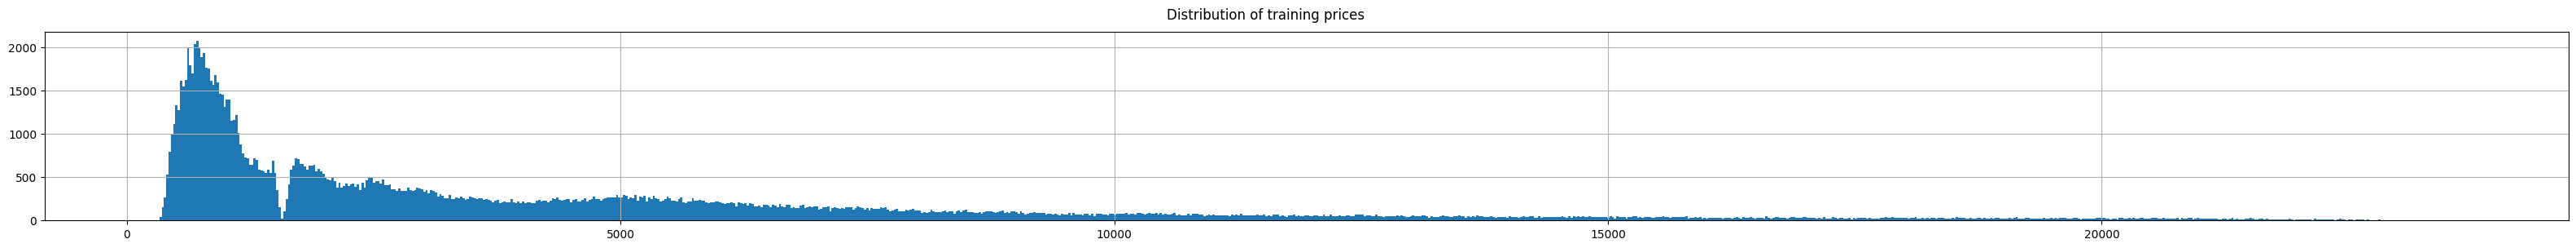

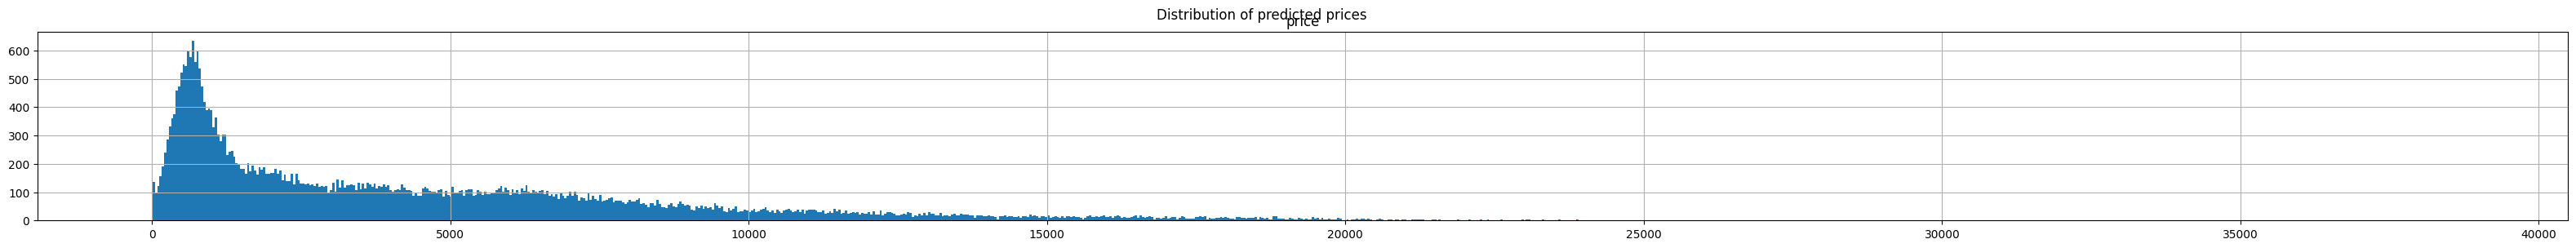

In [ ]:
pY = pd.DataFrame(m.predict(vX_in), index=range(1,len(vX)+1), columns=['price'])  # ensure that labels and observations are in corresponding order
pY = pY.clip(lower=10)  # ensures no negative prices
_ = tY.hist(figsize=(40,3), bins=1000);  _ = plt.suptitle("Distribution of training prices");
_ = pY.hist(figsize=(40,3), bins=1000);  _ = plt.suptitle("Distribution of predicted prices");
ToCSV(pY, '💎Baseline🐍')

In [ ]:
# code to send the submition to kaggle from the notebook
# kaggle competitions submit -c 26-first-kaggle-competition-diamonds -f 💎Baseline🐍.csv -m "Message"

<font color=green><h3><b>$\epsilon$. Documentation</b></h3></font>

<font color=green><h4><b>Task 1. Explain Decisions in Preprocessing Pipeline</b></h4></font>

<font color=green>
Explain elements of your preprocessing pipeline i.e. feature engineering, subsampling, clustering, dimensionality reduction, etc.</font>

<font color=green>

1. Why did you choose these elements? (Something in EDA, prior experience,...? Note: EDA is not required)
1. How do you evaluate the effectiveness of these elements?
1. What else have you tried that worked or didn't?

</font>

<font color=red><b>Your answer here.</b></font>

<font color=green><h4><b>Task 2. Explain Decisions in Modeling Pipeline</b></h4></font>

<font color=green>
Explain your modeling approach, i.e. ideas you tried and why you thought they would be helpful.

1. How did these decisions guide you in modeling?
1. How do you evaluate the effectiveness of these elements?
1. What else have you tried that worked or didn't?

</font>

<font color=red><b>Your answer here.</b></font>

<font color=green><h3><b>$\zeta$. References</b></h3></font>

<font color=red><b>Your answer here.</b></font>

<font color=green>
Cite your sources to help your peers learn from these (and to avoid plagiarism claims). At the least, ISLP textbook should be cited. Use Google Scholar to draw APA citation format for books and publications. Also cite StackOverflow, package documentation, and other meaningful internet resources.

1. ...
1. ...

<font color=green><h4><b>$\epsilon$. LLM Documentation if used</b></h4></font>

<font color=red><b>Your answer here.</b></font>

<font size=5>⌛</font> <strong><font color=green size=5>Do not exceed competition's runtime limit! Do not write code outside TGP</font></strong>
<hr color=green size=40>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 9 sec


## 💡**Starter Ideas**

1. Tune model hyperparameters
1. Try to linear and non-linear feature normalization: shift/scale, log, divide features by features (investigate scatterplot matrix)
1. Try higher order feature interactions ($x_i^a$, $x_ix_j$, ...) to identify new key features or their linear combinations. With too many features you can use a smaller subsample or reduce dimensionality of feature space using [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [tSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html), or [UMAP](https://umap-learn.readthedocs.io/en/latest/).
1. Do a thorough EDA and understand non-linear relation in I/O. Are any interactions more special than others (E.g. is diamond *volume* a better predictor?)
1. If you note a shift in trend for any predictors, try building a model for each trend.
1. Evaluate predictions and focus on poorly predicted "groups". Can they be identified and modeled separately?
1. Do scatter plots show piecewise linear shape? Can a separate linear model be used on each support of approximately linear X-Y relation?
1. How are categorical features treated by the SKLearn models? Is there a [better way](https://www.google.com/search?q=ways+to+encode+categorical+data) to encode these (perhaps, ordinal) features?
  1. E.g. you could replace codes (or groups of codes) with their frequencies, which may capture the implied "distance" or rarity between category levels.
  1. If encoding ordinal features with integers, should non-equidistant values be considered?
1. Learn about [modeling price of a diamond](https://www.google.com/search?q=machine+learning+model+price+diamond).
1. Try post-processing: shifting/scaling/transforming the distribution of predicted prices `pY` to match the distribution of training prices `tY`


# The previous part was basline Kaggle , now let's continue our seminar

In [ ]:
from sklearn.model_selection import train_test_split as tts
import seaborn as sns, statsmodels.api as sm
from sklearn.metrics import r2_score


In [ ]:
df = pd.read_csv('XY_diamonds.csv'); df


,carat,depth,table,x,y,z,cut,color,clarity,price
0,0.35,67.2,57.1,4.64,4.69,2.87,I,G,VS1,NaN
1,1.64,67.3,60.7,7.84,7.82,4.94,V,E,SI1,NaN
...,...,...,...,...,...,...,...,...,...,...
199998,0.48,68.7,53.0,4.47,4.45,2.72,I,G,IF,1474.0
199999,0.48,65.0,64.7,5.60,5.62,3.44,I,H,VS2,765.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   carat    200000 non-null  float64
 1   depth    200000 non-null  float64
 2   table    200000 non-null  float64
 3   x        200000 non-null  float64
 4   y        200000 non-null  float64
 5   z        200000 non-null  float64
 6   cut      200000 non-null  object 
 7   color    200000 non-null  object 
 8   clarity  200000 non-null  object 
 9   price    160000 non-null  float64
dtypes: float64(7), object(3)
memory usage: 15.3+ MB


Let's split part we may use for training purposes and the one we have to predict to send to Kaggle

In [ ]:
df_to_predict = df.query('price!=price').drop('price', axis=1)  # slice a kaggle test sample
df_to_train = df.query('price==price')  # slice training sample

In [ ]:
df_to_predict.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    40000 non-null  float64
 1   depth    40000 non-null  float64
 2   table    40000 non-null  float64
 3   x        40000 non-null  float64
 4   y        40000 non-null  float64
 5   z        40000 non-null  float64
 6   cut      40000 non-null  object 
 7   color    40000 non-null  object 
 8   clarity  40000 non-null  object 
dtypes: float64(6), object(3)
memory usage: 3.1+ MB


In [ ]:
df = df_to_train.copy()

In [ ]:
df.describe()

,carat,depth,table,x,y,z,price
count,160000.00,160000.00,160000.00,160000.00,160000.00,160000.00,160000.00
mean,0.80,67.86,57.45,5.73,5.74,3.54,4487.57
...,...,...,...,...,...,...,...
75%,1.07,69.80,63.10,6.63,6.62,4.09,6160.25
max,5.76,86.60,96.10,11.79,65.41,8.95,23566.00


## Correlation plot

Typically we avoid redundancy, whenever possible. Here for the sake of demonstrating an alternative method, we use the seaborn library to plot a correlation matrix. Notably, this quantifies the qualitative images we saw above.

**Why:** We want to evaluate the linear relationships among all variables. This suggests the important helpful (correlating with) and problematic features.

**Takeaway:**
* The correlation between `price` and some other features is less than 0.5 in absolute values so we may want to try to go beyond a linear model to reveal non-linear dependencies.
* We observe strong correlations for some features -- there could be multicollinearity problems.




In [ ]:
df.select_dtypes("number").corr()

,carat,depth,table,x,y,z,price
carat,1.00,0.02,0.06,0.81,0.79,0.81,0.90
depth,0.02,1.00,-0.05,-0.01,-0.01,0.04,-0.03
...,...,...,...,...,...,...,...
z,0.81,0.04,0.52,0.99,0.97,1.00,0.75
price,0.90,-0.03,0.04,0.76,0.74,0.75,1.00


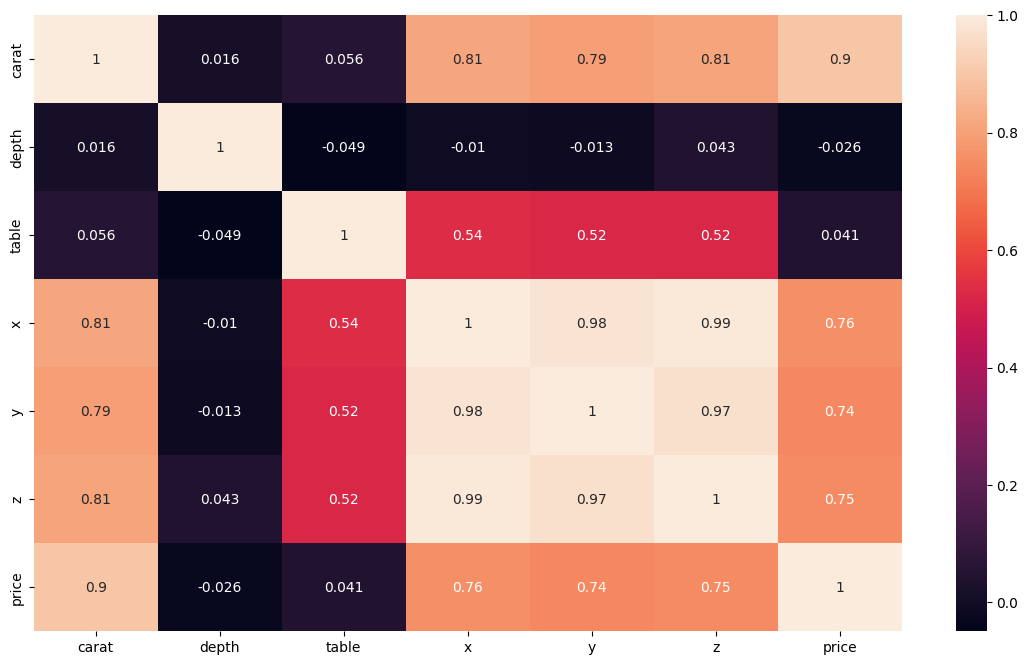

In [ ]:
plt.figure(figsize=(14, 8))
ax = sns.heatmap(df.select_dtypes("number").corr(), annot=True);

## Relationships

**Why:** The stats above value hint on relationships among our variables. We can build a quick visualization to evaluate any potentially strong relationship, which can either help or hurt the model. The relationships with response are beneficial, while the relationships among features are problematic. The latter introduce redundancy into the dataset. This could cause instability and hinder interpretability of trained regression parameters.

**Takeaway:**

Scatterplots
* The relationships among features are not obvious.
* Some of them a strongly correlated, some of them are not.
* We should also consider some transformations of features that would strengthen their explanatory power, at least, in a linear model.

Histograms
* some variables have uniform distribution, some -- triangular, some -- even descrete




<Figure size 1400x800 with 0 Axes>

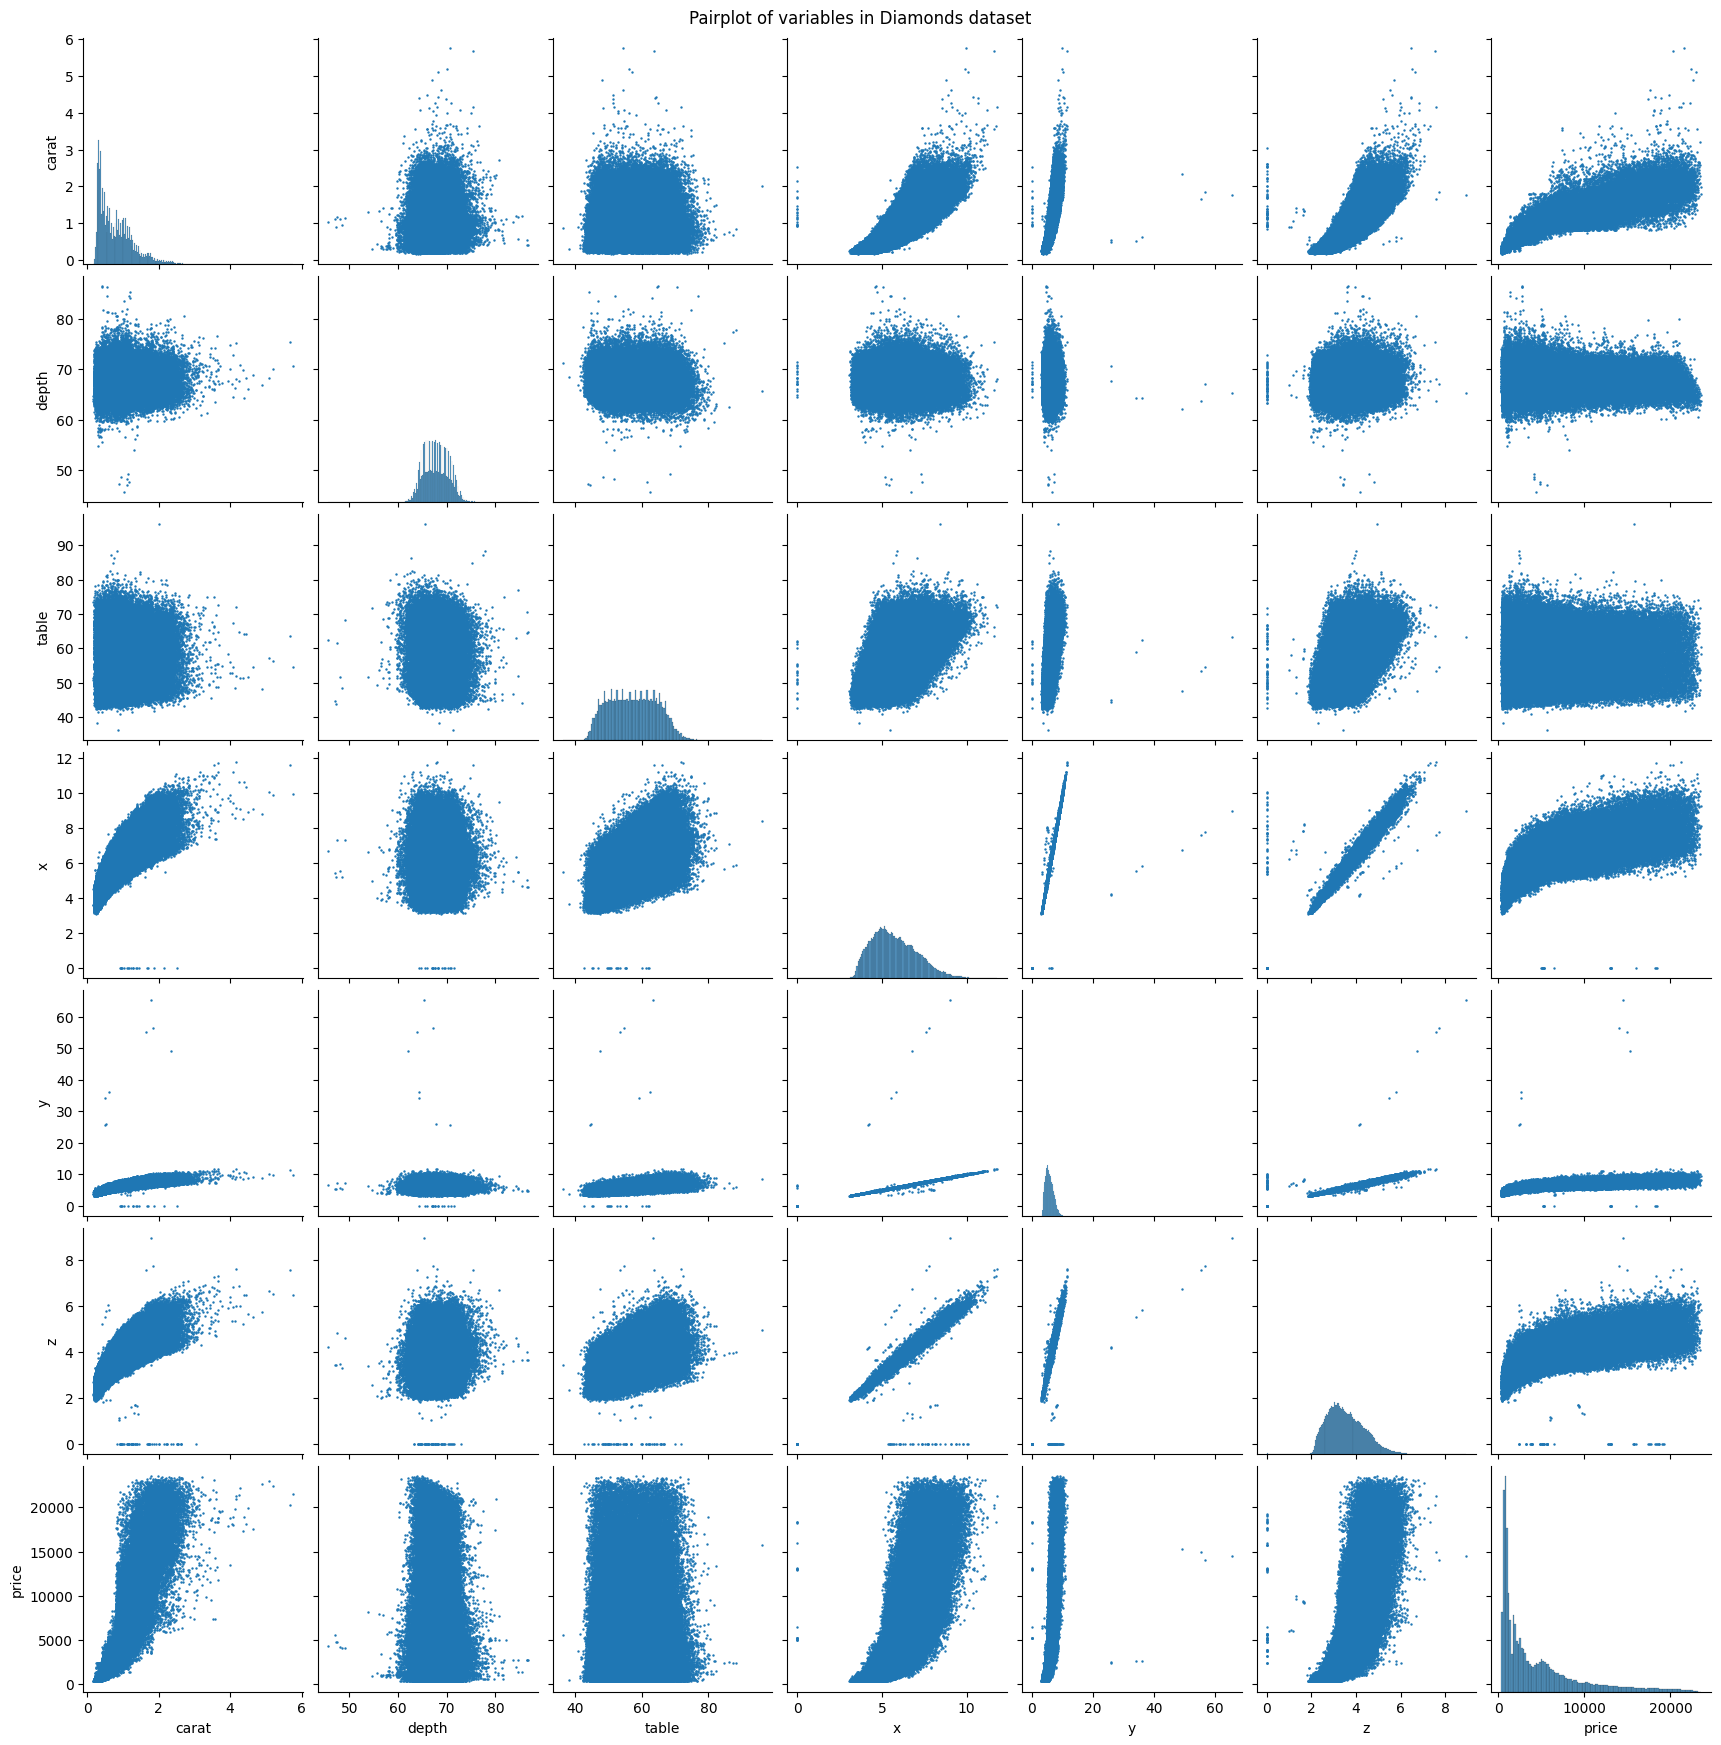

In [ ]:
plt.figure(figsize=(14, 8));
ax = sns.pairplot(df, plot_kws=dict(linewidth=0, s=3));
ax.fig.suptitle("Pairplot of variables in Diamonds dataset", y=1);

## Baseline model, v0 (version 0)


### Train and test observations

We first need to (*randomly!*) split the observations into train and test sets. Then train model on train observations and evaluate on the test observations. For reproducibility, we always seed our models with any number (zero is good as any). We hold out 20% of observations for computing **out-of-sample** (testing) performance.

IMPORTANT: It is absolutely crucial to assure your response variable is not part of the input. Such **leakage** is a typical mistake. If your model's results are too good to be true, suspect leakage.

We have
* `X_train` are training features
* `X_test` are the corresponding training responses
* `y_train` are validation (testing) features
* `y_test` are the corresponding validation (testing) responses.

**Takeaway:** Finally, we do a sanity check and confirm that
* we have 128000 train responses and 128000 train observations
* 32000 test responses and 32000 test observations.
* 6 features go into the model during training.
* 6 features go into the model during testing.
* Notice we have eliminated categorical features for learning purposes, but you may want to use them during the competition



In [ ]:
df.head()

,carat,depth,table,x,y,z,cut,color,clarity,price
40000,0.36,69.5,61.3,4.58,4.52,2.84,P,H,VS1,714.0
40001,0.87,70.7,56.3,6.69,6.74,4.19,I,G,VS2,7504.0
...,...,...,...,...,...,...,...,...,...,...
40003,0.30,69.6,69.8,5.15,5.11,3.10,P,D,VS2,923.0
40004,0.60,68.6,49.4,4.88,4.91,2.96,P,E,SI1,2873.0


In [ ]:
target_variable = 'price'
df_numberic = df.select_dtypes("number")
X_train, X_test, y_train, y_test = tts(df_numberic.drop(target_variable, axis=1), df_numberic[target_variable], test_size=0.2, random_state=42)

print(f'Sanity check for dimensions of variables: {X_train.shape, X_test.shape, y_train.shape, y_test.shape}')

Sanity check for dimensions of variables: ((128000, 6), (32000, 6), (128000,), (32000,))


**Why:** A rapid prototyping will produce an immediate feedback on our minimal efforts. We will use the results of the model v0 as a benchmark in the next iteration. If v1 model outperforms v0, we'll keep v1. Otherwise, we'll try different alterations.

**Takeaway:**
* The $R^2_{\text{OOS}}=0.903$ is very high, but we did observe strong correlations between inputs and response and low correlations among inputs. So, this result is not unusual and leakage is not a concern.
* This baseline model has no bias (intercept) term in the table of coefficients. Perhaps adding it in v1 model would improve the $R^2_{\text{OOS}}$.




In [ ]:
mdl = sm.OLS(y_train, X_train)     # training on train observations
fmdl = mdl.fit()

In [ ]:
fmdl.summary(title='Baseline model for Diamonds dataset', alpha=.01)

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Baseline model for Diamonds dataset                          
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.903
Model:                            OLS   Adj. R-squared (uncentered):              0.903
Method:                 Least Squares   F-statistic:                          1.976e+05
Date:                Tue, 13 Jan 2026   Prob (F-statistic):                        0.00
Time:                        15:25:17   Log-Likelihood:                     -1.1572e+06
No. Observations:              128000   AIC:                                  2.314e+06
Df Residuals:                  127994   BIC:                                  2.314e+06
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.005      0.995]
------------------------------------------------------------------------------
carat       6495.0721     31.638    205.290      0.000    6413.576    6576.569
depth        -15.9461      0.709    -22.479      0.000     -17.773     -14.119
table       -101.0641      1.475    -68.536      0.000    -104.863     -97.266
x           1398.6494     37.042     37.758      0.000    1303.234    1494.065
y            226.7468     20.263     11.190      0.000     174.552     278.941
z           -886.1182     50.244    -17.636      0.000   -1015.539    -756.697
==============================================================================
Omnibus:                    32904.271   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           191034.004
Skew:                           1.113   Prob(JB):                         0.00
Kurtosis:                       8.555   Cond. No.                         929.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
y_pred = fmdl.predict(X_test)   # predicted values on the testing set
print(f'Out of sample R^2 is {r2_score(y_test, y_pred):.2f}')

Out of sample R^2 is 0.81


In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error
print(f'Out of sample MSE is {mean_squared_error(y_test, y_pred):.2f}')
print(f'Out of sample RMSE is {root_mean_squared_error(y_test, y_pred):.2f}')

Out of sample MSE is 4207615.47
Out of sample RMSE is 2051.25


Here we may now make predictions for the Kaggle evaluation set

In [ ]:
kaggle_predictions = fmdl.predict(df_to_predict.select_dtypes("number"))
kaggle_predictions.head()

,0
0,447.09
1,11809.72
...,...
3,-737.97
4,29.00


In [ ]:
def to_csv(df: pd.DataFrame, fname: str) -> None:
  df.round(2).to_csv(f'{fname}.csv', index_label='id')

In [ ]:
kaggle_predictions.index += 1
to_csv(kaggle_predictions.clip(10), "💎Baseline🐍")

In [ ]:
# to submit to kaggle from jupyter notebook
!kaggle competitions submit -c 26-first-kaggle-competition-diamonds -f 💎Baseline🐍.csv -m "Submission via API"

This was the basic pipeline for the kaggle competition

## Version 1

Let's add constant term and rerun the model fit

**Why:** We are trying to improve a model and fix possible issues

**Takeaway:**
* The $R^2_{\text{OOS}}=0.84$ -- small improvement over v0
* Multicollinearity is still present -- we might need to fix it in v2

In [ ]:
target_variable = 'price'
columns_to_drop = [target_variable]
X_train, X_test, y_train, y_test = tts(df_numberic.drop(columns_to_drop, axis=1), df_numberic[target_variable], test_size = 0.2, random_state=42)
print(f'Sanity check for dimensions of variables: {X_train.shape, X_test.shape, y_train.shape, y_test.shape}')

Sanity check for dimensions of variables: ((128000, 6), (32000, 6), (128000,), (32000,))


In [ ]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [ ]:
mdlv2 = sm.OLS(y_train, X_train)     # training on train observations
fmdlv2 = mdlv2.fit()

In [ ]:
fmdlv2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                 9.488e+04
Date:                Tue, 13 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:27:43   Log-Likelihood:            -1.1569e+06
No. Observations:              128000   AIC:                         2.314e+06
Df Residuals:                  127993   BIC:                         2.314e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4066.3087    173.585     23.425      0.000    3726.086    4406.532
carat       6421.0775     31.729    202.375      0.000    6358.890    6483.265
depth        -70.4759      2.433    -28.966      0.000     -75.245     -65.707
table       -109.6045      1.516    -72.300      0.000    -112.576    -106.633
x           1205.5930     37.871     31.834      0.000    1131.367    1279.819
y            187.8152     20.288      9.257      0.000     148.051     227.579
z           -457.1996     53.375     -8.566      0.000    -561.814    -352.585
==============================================================================
Omnibus:                    32828.485   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           183758.986
Skew:                           1.121   Prob(JB):                         0.00
Kurtosis:                       8.424   Cond. No.                     2.75e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.75e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
y_pred = fmdlv2.predict(X_test)   # predicted values on the testing set
print(f'Out of sample R^2 is {r2_score(y_test, y_pred):.2f}')

Out of sample R^2 is 0.81


In [ ]:
from sklearn.metrics import mean_squared_error
print(f'Out of sample MSE is {mean_squared_error(y_test, y_pred):.2f}')
print(f'Out of sample RMSE is {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')

Out of sample MSE is 4189217.25
Out of sample RMSE is 2046.76


# Multivariate linear regression by hands

Let's try to see what happens under the hood of statsmodel.OLS

**Why:** We want to understand the equations and possible issues for calculating coefficients

**Takeaway:**
* We have several ways to calculate by hands, but the result remains the same



In [ ]:
X_train, X_test, y_train, y_test = tts(
  df_numberic.drop(columns_to_drop, axis=1),
  df_numberic[target_variable],
  test_size=0.2,
  random_state=42
)

In [ ]:
X_train.head()

,carat,depth,table,x,y,z
190477,1.66,67.2,68.1,8.61,8.67,5.32
155280,0.32,68.1,56.0,4.38,4.40,2.75
...,...,...,...,...,...,...
90780,0.34,68.7,62.8,4.89,4.92,3.04
76702,0.32,66.8,54.6,4.25,4.29,2.52


In [ ]:
X_train["const"] = 1

In [ ]:
X_train.head()

,carat,depth,table,x,y,z,const
190477,1.66,67.2,68.1,8.61,8.67,5.32,1
155280,0.32,68.1,56.0,4.38,4.40,2.75,1
...,...,...,...,...,...,...,...
90780,0.34,68.7,62.8,4.89,4.92,3.04,1
76702,0.32,66.8,54.6,4.25,4.29,2.52,1


In [ ]:
import numpy as np

In [ ]:
X_train, X_test, y_train, y_test = tts(
  df_numberic.drop(columns_to_drop, axis=1).to_numpy(),
  df_numberic[target_variable].to_numpy(),
  test_size=0.2,
  random_state=42,
)

In [ ]:
np.column_stack([np.ones(X_train.shape[0]), X_train])

array([[1.  , 1.66, ..., 8.67, 5.32],
       [1.  , 0.32, ..., 4.4 , 2.75],
       ...,
       [1.  , 1.41, ..., 6.81, 4.21],
       [1.  , 0.89, ..., 4.89, 3.06]])

In [ ]:
# # Add the column of ones
X_plus_ones = np.column_stack((np.ones(X_train.shape[0]), X_train))
X_test_plus_ones = np.column_stack((np.ones(X_test.shape[0]), X_test))
X_plus_ones.shape

(128000, 7)

More ideas to consider!

1. Tune model hyperparameters
1. Try to linear and non-linear feature normalization: shift/scale, log, divide features by features (investigate scatterplot matrix)
1. Try higher order feature interactions ($x_i^a$, $x_ix_j$, ...) to identify new key features or their linear combinations. With too many features you can use a smaller subsample or reduce dimensionality of feature space using [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [tSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html), or [UMAP](https://umap-learn.readthedocs.io/en/latest/).
1. Do a thorough EDA and understand non-linear relation in I/O. Are any interactions more special than others (E.g. is diamond *volume* a better predictor?)
1. If you note a shift in trend for any predictors, try building a model for each trend.
1. Evaluate predictions and focus on poorly predicted "groups". Can they be identified and modeled separately?
1. Do scatter plots show piecewise linear shape? Can a separate linear model be used on each support of approximately linear X-Y relation?
1. How are categorical features treated by the SKLearn models? Is there a [better way](https://www.google.com/search?q=ways+to+encode+categorical+data) to encode these (perhaps, ordinal) features?
  1. E.g. you could replace codes (or groups of codes) with their frequencies, which may capture the implied "distance" or rarity between category levels.
  1. If encoding ordinal features with integers, should non-equidistant values be considered?
1. Learn about [modeling price of a diamond](https://www.google.com/search?q=machine+learning+model+price+diamond).
1. Try post-processing: shifting/scaling/transforming the distribution of predicted prices to match the distribution of training prices


## Task: implement OLS using numpy matrix operations.

Recall the OLS method for some data matrix $X$, coefficients $\theta$ and a vector of output variables $y$:
$$X \cdot \theta = y$$
$$X^T X \theta = X^T y$$
Finally:
$$\theta = (X^T X )^{-1} X^T y$$

Compute the coefficients using `np.matmul`, `np.linalg.inv` and the `.T` operation.

In [ ]:
np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

array([6495.07,  -15.95, -101.06, 1398.65,  226.75, -886.12])

In [ ]:
coefficients_analytical = np.matmul(np.matmul(np.linalg.inv(np.matmul(X_train.T, X_train)),
                                  X_train.T), y_train)

In [ ]:
coefficients_analytical

array([6495.07,  -15.95, -101.06, 1398.65,  226.75, -886.12])

In [ ]:
mdl = sm.OLS(y_train, X_train) # training on train observations
fmdl = mdl.fit()
print(fmdl.summary(title='Second iteration for Diamonds dataset', alpha=.01))
y_pred = fmdl.predict(X_test) # predicted values on the testing set
print(f'Out of sample R^2 is {r2_score(y_test, y_pred):.2f}')

                         Second iteration for Diamonds dataset                         
Dep. Variable:                      y   R-squared (uncentered):                   0.903
Model:                            OLS   Adj. R-squared (uncentered):              0.903
Method:                 Least Squares   F-statistic:                          1.976e+05
Date:                Tue, 13 Jan 2026   Prob (F-statistic):                        0.00
Time:                        15:27:44   Log-Likelihood:                     -1.1572e+06
No. Observations:              128000   AIC:                                  2.314e+06
Df Residuals:                  127994   BIC:                                  2.314e+06
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.005      0.995]
-----------------------------------------

In [ ]:
y_pred_numpy = X_test @ coefficients_analytical

In [ ]:
root_mean_squared_error(y_test, y_pred_numpy)

2051.24729663915

In [ ]:
1 - ((y_train - (X_train @ coefficients_analytical)) ** 2).sum() / ((y_train - y_train.mean()) ** 2).sum()

np.float64(0.8156499523357452)

In [ ]:
np.sqrt(((y_test - (X_test @ coefficients_analytical)) ** 2).mean())

np.float64(2051.24729663915)

Compare these coefficients with the ones we obtained from `sm.OLS` earlier.

## Better ways to implement OLS regression


$$X \cdot \theta = y$$
$$X^T X \theta = X^T y$$
Finally:
$$\theta = (X^T X )^{-1} X^T y$$


In [ ]:
# sligtly better way
theta_analytical_v2 = np.linalg.solve(np.matmul(X_train.T, X_train), np.matmul(X_train.T, y_train))
theta_analytical_v2

array([6495.07,  -15.95, -101.06, 1398.65,  226.75, -886.12])

In [ ]:
# optimized way
theta_analytical_v3 = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
theta_analytical_v3

array([6495.07,  -15.95, -101.06, 1398.65,  226.75, -886.12])

# kNN for regression

**Why:** Since we saw that there are a lot of non-linear dependencies, indeed let's try to use something nonlinear. We start from kNN

**Takeaway:** We see that very simple approach with only 5 neighbours works worse than our baseline model. Let's try to go further and scale our features



## Auto Data Set with Pandas DataFrame

We can load dataframe directly from URL (where all textbook data files are stored).

**Why**: We want to evaluate the *Auto* data matrix in Colab and observe its structure and values.

**Takeaway**:
* From results below we learn that our dataframe `df` has 397 observations and 9 variables.
* All values except name appear numeric.
* We have 5 objects with missing values.

In [ ]:
csv_url = 'https://raw.githubusercontent.com/omelnikov/data/main/auto/auto.csv'  # assign file path to a variable
df = pd.read_csv(csv_url).drop(["name"], axis=1).dropna()
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
...,...,...,...,...,...,...,...,...
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [ ]:
target_variable = 'mpg'
X_train, X_test, y_train, y_test = tts(df.drop(target_variable, axis=1), df[target_variable], test_size = 0.2, random_state=42)
print(f'Sanity check for dimensions of variables: {X_train.shape, X_test.shape, y_train.shape, y_test.shape}')

Sanity check for dimensions of variables: ((313, 7), (79, 7), (313,), (79,))


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=3, weights='uniform')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)   # predicted values on the testing set
print(f'\n\nOut of sample R^2 is {r2_score(y_test, y_pred):.2f}')

KNeighborsRegressor(n_neighbors=3)



Out of sample R^2 is 0.62


In [ ]:
from sklearn.metrics import mean_squared_error
print(f'Out of sample MSE is {mean_squared_error(y_test, y_pred):.2f}')
print(f'Out of sample RMSE is {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')

Out of sample MSE is 19.63
Out of sample RMSE is 4.43


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler = scaler.fit(X_train)

standardized_X = scaler.transform(X_train)
standardized_X_test = scaler.transform(X_test)

In [ ]:
pd.DataFrame(standardized_X, columns=X_train.columns).describe()

,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,3.13e+02,3.13e+02,3.13e+02,3.13e+02,3.13e+02,3.13e+02,3.13e+02
mean,1.48e-16,3.97e-17,-1.48e-16,2.55e-16,5.65e-16,-1.80e-15,1.72e-16
...,...,...,...,...,...,...,...
75%,1.48e+00,1.03e+00,6.39e-01,7.85e-01,6.24e-01,7.70e-01,5.51e-01
max,1.48e+00,2.50e+00,3.28e+00,2.56e+00,3.29e+00,1.60e+00,1.79e+00


In [ ]:
knn = KNeighborsRegressor(n_neighbors=3, weights='uniform')
knn.fit(standardized_X, y_train)
y_pred = knn.predict(standardized_X_test)   # predicted values on the testing set
print(f'\n\nOut of sample R^2 is {r2_score(y_test, y_pred):.2f}')

KNeighborsRegressor(n_neighbors=3)



Out of sample R^2 is 0.86


In [ ]:
from sklearn.metrics import mean_squared_error
print(f'Out of sample MSE is {mean_squared_error(y_test, y_pred):.2f}')
print(f'Out of sample RMSE is {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')

Out of sample MSE is 7.15
Out of sample RMSE is 2.67


In [ ]:
x_var = 2
var_name = X_train.columns[x_var]
xx_train = X_train.iloc[:, x_var].values.reshape(-1, 1)
xx_test = X_test.iloc[:, x_var].values.reshape(-1, 1)
x_grid = np.linspace(xx_train.min(), xx_train.max(), 100).reshape(-1, 1)

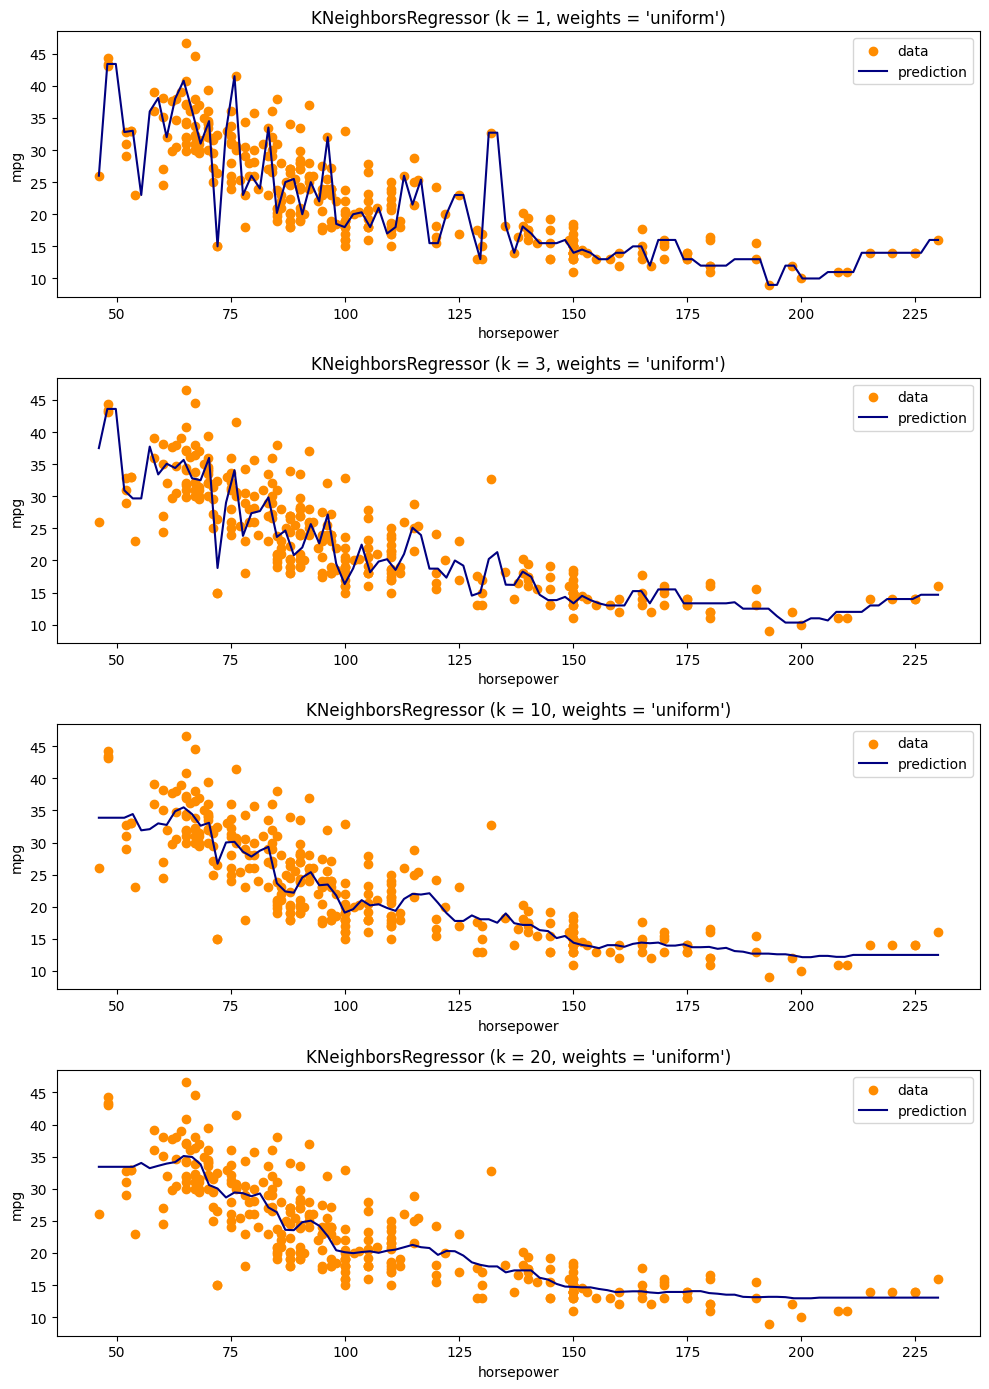

In [ ]:
weights = 'uniform'

plt.figure(figsize=(10, 14))

for i, n_neighbors in enumerate([1, 3, 10, 20]):
    knn = KNeighborsRegressor(n_neighbors, weights=weights)
    knn.fit(xx_train, y_train.values)

    y_grid = knn.predict(x_grid)

    plt.subplot(4, 1, i + 1);
    plt.scatter(xx_train, y_train, color='darkorange', label='data');
    plt.plot(x_grid, y_grid, color='navy', label='prediction');
    plt.axis('tight');
    plt.ylabel(target_variable)
    plt.xlabel(var_name);
    plt.legend();
    plt.title("KNeighborsRegressor (k = %i, weights = '%s')" % (n_neighbors, weights));

plt.tight_layout();
plt.show();

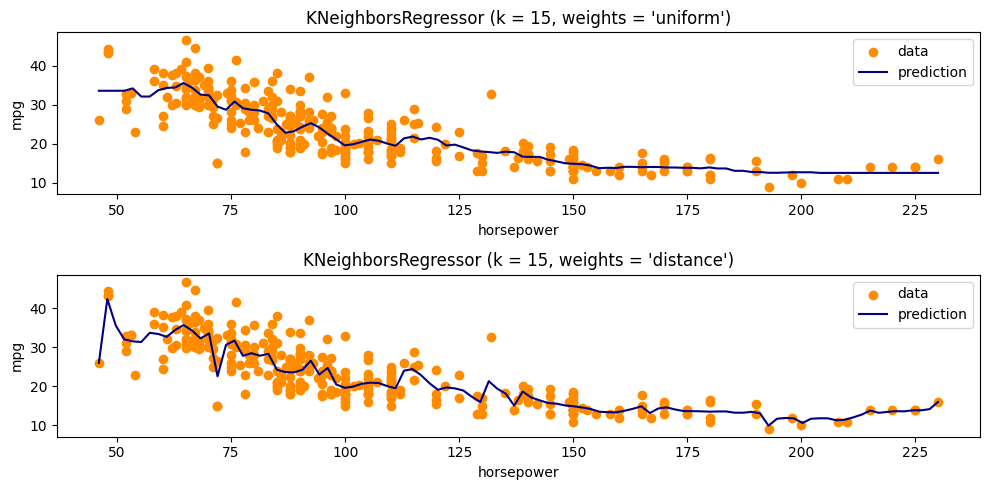

In [ ]:
n_neighbors = 15

plt.figure(figsize=(10, 5))

for i, weights in enumerate(['uniform', 'distance']):
    knn = KNeighborsRegressor(n_neighbors, weights=weights)
    knn.fit(xx_train, y_train.values)

    y_grid = knn.predict(x_grid)

    plt.subplot(2, 1, i + 1);
    plt.scatter(xx_train, y_train, color='darkorange', label='data');
    plt.plot(x_grid, y_grid, color='navy', label='prediction');
    plt.axis('tight');
    plt.ylabel(target_variable)
    plt.xlabel(var_name);
    plt.legend();
    plt.title("KNeighborsRegressor (k = %i, weights = '%s')" % (n_neighbors, weights));

plt.tight_layout();
plt.show();

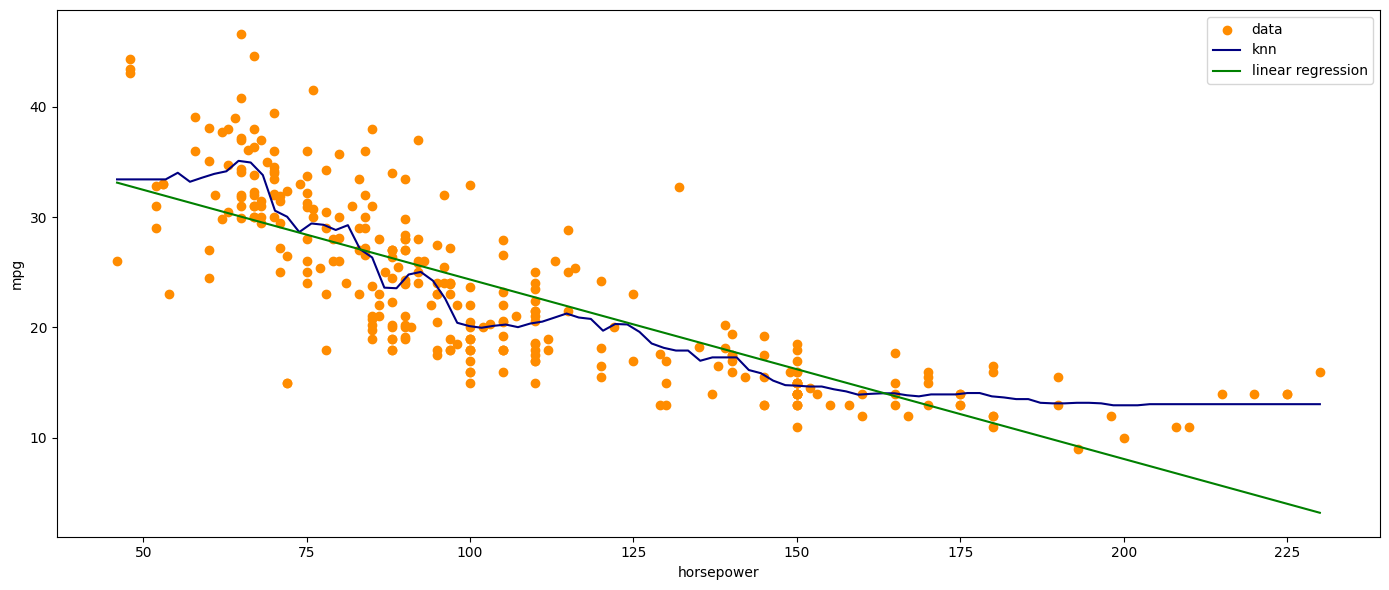

In [ ]:
plt.figure(figsize=(14, 6))
plt.scatter(xx_train, y_train, color='darkorange', label='data')

# knn prediction
knn = KNeighborsRegressor(n_neighbors=20, weights='uniform')
knn.fit(xx_train, y_train.values)
y_grid = knn.predict(x_grid)
plt.plot(x_grid, y_grid, color='navy', label='knn')
#print(f'kNN Regressor \n\nOut of sample R^2 is {r2_score(y_test, y_grid):.2f}')

# linear regression prediction
mdl = sm.OLS(y_train.values, sm.add_constant(xx_train)).fit()    # training on train observations
y_grid = mdl.predict(sm.add_constant(x_grid))   # predicted values on the testing set
plt.plot(x_grid, y_grid, color='green', label='linear regression');
#print(f'OLS \n\nOut of sample R^2 is {r2_score(y_test, y_grid):.2f}')


plt.ylabel(target_variable)
plt.xlabel(var_name);
plt.axis('tight');
plt.legend();

plt.tight_layout();
plt.show();